#**1- Bibliotecas**

##1.1- Carregando bibliotecas

In [5]:
#é melhor importar apenas as partes usadas do SKlearn para execução mais rápida e menos gasto de memóriaimport math
import io
import numpy as np
import pandas as pd

#Arquivos e criptografia
import requests
from cryptography.fernet import Fernet

#Gráficos
import matplotlib.pyplot as plt
import plotly.express as px #o Douglas pediu pra usar Plotly para gráficos mais interativos.
import seaborn as sns

#Partes da Pipeline e pipeline completa
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, MinMaxScaler

#Modelos
from sklearn.linear_model import LinearRegression

#Modelos em árvore
#árvore pura
from sklearn.tree import DecisionTreeRegressor
from sklearn.tree import DecisionTreeClassifier
#import xgboost as xgb --- XGBoost foi removido; Vamos nos limitar ao SKLearn por enquanto.
#árvore -> Ensemble -> Boosting
from sklearn.ensemble import GradientBoostingRegressor
#árvore -> Ensemble -> Bagging
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import RandomForestClassifier
#para a importância de permutação das redes neurais
from sklearn.inspection import permutation_importance

from sklearn.svm import SVR
from sklearn.linear_model import ElasticNet
from sklearn.linear_model import Lasso
from sklearn.linear_model import Ridge

#Métricas
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

#checagem do diretório do ambiente
import os
print(os.getcwd()) # de qual diretório tá saindo, e onde está "buscando" arquivos
print(os.listdir()) # o que tem nesse diretório

/content
['.config', 'sample_data']


#**2- Funções**

In [10]:
%%capture
# %%capture é um comando mágico do IPy de redirecionar a saída do código para a saída especificada (como out para stdout, etc) ou suprimi-la caso não haja saída especificada.
# @title 2.1- Quebrar texto
def quebrar_texto(texto, limite=20):
  """Adiciona uma quebra de linha em [texto] a cada [limite] caracteres. O [limite] padrão é 20."""
  tamanho = len(texto)
  num_fatias = (tamanho//limite)+1
  if num_fatias <= 1:
    return texto
  caracteres = list(texto)
  pontos_de_quebra=[]

  for i in range(1, num_fatias):
    ponto_ideal = tamanho//num_fatias * i
    distancia_min = float('inf') #joga a barra lá em cima pra qualquer um passar embaixo
    melhor_ponto = -1 #melhor ponto só vai se manter -1 caso não haja nenhum espaço no texto

    for j in range(len(caracteres)):
      if caracteres[j] == ' ':
        if abs(ponto_ideal-j) < distancia_min:
          distancia_min = abs(ponto_ideal-j)
          melhor_ponto = j
    if melhor_ponto != -1 and melhor_ponto not in pontos_de_quebra:
      pontos_de_quebra.append(melhor_ponto)

  for pos in sorted(pontos_de_quebra):
    caracteres[pos] = '\n'
  return ''.join(caracteres)

print(f"--- Limite 20 ---\n{quebrar_texto('leonciobolas', 20)}")
print(f"\n--- Limite 20 (1 quebra) ---\n{quebrar_texto('leonciobolas de mais que 20 caract', 20)}")
print(f"\n--- Limite 20 (2 quebras) ---\n{quebrar_texto('leonciobolas é um jogador de jogos first person shooter que exprime a inspiração de seus espectadores.', 20)}")

In [11]:
#@title 2.2- Destacar linhas no display
def destacar_linhas(linha, indices, fundo_cor=(0, 0, 200), cor_fonte=(255, 255, 0)):
    """Destaca uma ou mais linhas do display aplicando as cores de fundo e fonte RGB escolhidas."""
    fundo_cor_str = f'rgb({fundo_cor[0]}, {fundo_cor[1]}, {fundo_cor[2]})'
    cor_fonte_str = f'rgb({cor_fonte[0]}, {cor_fonte[1]}, {cor_fonte[2]})'
    if linha.name in indices:
        return [f'background-color: {fundo_cor_str}; color: {cor_fonte_str}; font-weight: bold; font-style: italic'] * len(linha)
    else:
        return [''] * len(linha)

In [12]:
#@title 2.3- Plot 3D Scatter
def plot3Dscatter(dataframe, eixox='X', eixoy='Y', eixoz='Z', variavel=None, figsize=(15, 10)):
  """Os eixos são nomeados 'X' 'Y' 'Z' por padrão, [variavel] é uma quarta dimensão opcional a ser avaliada por código de cores nas coordenadas. O padrão de [figsize] é (15,20)."""

  #Primeiramente checamos se há uma quarta dimensão a ser avaliada.
  if variavel is None:
    df_temp = dataframe[[eixox, eixoy, eixoz]].dropna() #dropna remove valores NaN para evitar erros no plot.
    title_text = 'Coordenadas Espaciais'
  else:
    df_temp = dataframe[[eixox, eixoy, eixoz, variavel]].dropna()
    title_text = quebrar_texto(f'{variavel} em Coordenadas Espaciais', 30)

  # Criar o gráfico 3D de dispersão usando plotly.express
  fig = px.scatter_3d(
    df_temp,
    x=eixox,
    y=eixoy,
    z=eixoz,
    color=variavel if variavel else eixoy, # Se 'variavel' existe, usa para a cor, senão usa eixoy
    title=title_text,
    height=figsize[1]*50, # Ajusta a altura da figura com base no figsize
    width=figsize[0]*50 # Ajusta a largura da figura com base no figsize
  )

  # Atualizar o layout para melhor visualização
  fig.update_layout(
    scene = dict(
      xaxis_title=eixox,
      yaxis_title=eixoy,
      zaxis_title=eixoz
    ),
    title_x=0.5 # Centraliza o título
  )

  # Mostrar o gráfico interativo
  fig.show()

In [13]:
#@title 2.4- Plotar Histogramas
def plothistogramas(dataframe, colunas, grade=3, cor_grafico='red'):
    """Gera um grid de histogramas usando um laço For. Os padrões [grade] e [cor_grafico] são 3 e vermelho."""
    num_vars = len(colunas)
    linhas_grid = math.ceil(num_vars / grade)

    plt.figure(figsize=(18, 5 * linhas_grid))
    for i, coluna in enumerate(colunas, 1):
        plt.subplot(linhas_grid, grade, i)
        sns.histplot(data=dataframe, x=coluna, kde=True, color=cor_grafico)
        plt.title(quebrar_texto(coluna, grade*10))
        plt.xlabel('Distribuição')
        plt.ylabel('Frequência')
    plt.tight_layout()
    plt.show()

#**3- Carregando os dados**

##3.1- Abrindo o Dataframe

In [14]:
chave = b"Vl2y75bLXSEvC3mvwGPyfr3WIrFIj8kIYeDyPXKPn7M=" #CHAVE SECRETA DO NOSSO GRUPO
url = "https://raw.githubusercontent.com/leonetk/ICJ-Lab-Geomet/refs/heads/main/datasets/Geomet_Iron.csv.enc"

resposta = requests.get(url)
resposta.raise_for_status()

criptografados = resposta.content

fernet = Fernet(chave)
descriptografados = fernet.decrypt(criptografados)

In [15]:
df = pd.read_csv(io.BytesIO(descriptografados), encoding="latin-1") #o argumento encoding abre o arquivo com o encoding certo. 'cp1252' ou 'latin1' funcionam. O padrão é 'utf-8'.
#o read do pandas cria um objeto dataframe. É bem diferente do fopen() de C, por exemplo, que usa cria um controle de fluxo do arquivo, basicamente um cursor no conteúdo.
display(df)
rom_cols = df.filter(regex='ROM').columns.tolist() #filter é uma função do pandas, e regex significa regular expression (regular no sentido de padrão, repetição)
coluna_de_interesse = '%Rfe Flotação'

,Identificação,X,Y,Z,LitologiaReclassificação,Grau de liberação (%),%Fe_alim_ROM,%Al2O3_alim_ROM,%SiO2_alim_ROM,%P_alim_ROM,...,P Rej (%) Flot,Mn Rej (%) Flot,TiO2 Rej (%) Flot,CaO Rej (%) Flot,MgO Rej (%) Flot,PPC Rej (%) Flot,%RM Flotação,%Rfe Flotação,IS,Redução de SiO2 Flot
0,AGEOD_0144,666204.7297,7906404.535,919.860161,IF,99.418980,43.2,1.16,36.80,0.01,...,"<0,005","<0,008","<0,01",0.370,"<0,1",NaN,61.855159,92.364600,11.169192,85.138889
1,AGEOD_0150,665766.2400,7907195.038,945.297000,IF,99.554235,36.1,0.64,48.10,0.005,...,"<0,005",0.009,"<0,01",1.290,"<0,1",NaN,48.412698,90.391084,17.241075,93.507307
2,AGEOD_0154,665694.4630,7907296.270,946.654965,IF,98.635887,39.7,0.79,42.00,0.014,...,"<0,005","<0,008","<0,01",0.620,"<0,1",NaN,53.521825,92.738248,18.831407,93.720379
3,AGEOD_0160,665371.9224,7907596.069,965.757194,IF,97.597598,39.7,0.61,41.70,0.012,...,0.007,0.04,"<0,01",0.200,"<0,1",NaN,52.827381,88.423064,11.653077,89.779951
4,AGEOD_0162,666122.0950,7906620.532,924.532000,IF,99.611273,38.5,0.42,44.80,"<0,005",...,"<0,005","<0,008","<0,01",0.750,"<0,1",NaN,47.916667,85.298343,9.355423,87.803204
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
60,AGEOD_0512,666401.0972,7906801.617,863.964897,CGM,94.017094,64.4,1.87,1.37,0.055,...,0.118,0.02,0.34,0.140,0.19,8.200,99.272727,97.983012,2.574112,8.219178
61,AGEOD_0513,666399.8832,7906801.500,851.524655,CGM,94.674556,65.1,2.16,1.50,0.07,...,0.1635,0.01,0.385,0.145,0.155,9.725,98.727273,99.057877,1.490246,NaN
62,AGEOD_0523,666416.5090,7906602.563,856.783000,CGM,98.837209,63.6,2.67,1.97,0.142,...,0.161,0.01,0.35,0.160,0.13,8.250,99.454545,97.301799,2.461629,0.507614
63,AGEOD_0531,665799.8615,7907396.979,921.590637,CGM,100.000000,66.4,2.02,1.15,0.024,...,0.052,0.01,0.09,0.110,0.17,4.970,99.181818,97.803749,3.357802,2.247191


#**4 - Modelos que geram equações**

##4.1 - Regressão Linear com SKLearn
Usando scikit-learn, o processo geralmente envolve os seguintes passos:

O modelo é feito carregando a classe `LinearRegression` do `sklearn.linear_model`.
As variáveis independentes (`X`) e a variável dependente (`y`)  não podem ter valores ausentes e os tipos de dados devem ser  numéricos.

In [16]:
#Primeiro estávamos fazendo regressão linear univariada com '%Fe_alim_ROM' (rom_cols[0]) --
#Mas agora estamos considerando todas as variáveis ROM.

df_model = df[rom_cols + [coluna_de_interesse]].dropna() #coluna_de_interesse definida em 3.1 – categorização das variáveis
df_model = df_model.astype(float)
# ↳Algumas variáveis ('%P_alim_ROM', '%CaO_alim_ROM', '%MgO_alim_ROM') continham strings numéricas

X = df_model[rom_cols] #X precisa ser um DataFrame (ou ter formato 2D)
y = df_model[coluna_de_interesse] #Y pode ser uma Series (formato 1D)

print(f"Variáveis Independentes (Xizes): {rom_cols}")
print(f"Variável Dependente (Y): {coluna_de_interesse}\n")
print(f"Tamanho dos dados após remover NaNs: {df_model.shape[0]} linhas")

#Antes estávamos treinando com ressubstituição. Agora usaremos esse primeiro modelo linear como base, por isso, está sendo dividido com Hold Out.
#Hold Out 65:35
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.35, random_state=42, shuffle=True)

#Ajustando a escala dos dados de treino
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

#Instanciar e Treinar o Modelo
model = LinearRegression()
model.fit(X_train_scaled, y_train)


print(f"Quantidade total de amostras: {len(X)}")
print(f"Amostras de treinamento: {len(X_train)}")
print(f"Amostras de teste: {len(X_test)}")

print("Modelo de Regressão Linear (Hold Out) treinado com sucesso!")
#print(f"Coeficiente (inclinação): {model.coef_[0]:.4f}")
# ↳Removido pois agora temos múltiplos coeficientes.
for var, coef in zip(rom_cols, model.coef_):
    print(f"{var}:\t{coef:.4f}")

#zip() junta elementos de várias listas posicao por posicao:
#rom_cols = ["Fe", "SiO2", "Al2O3"]
#model.coef_ = [0.82, -0.15, 0.41]
#zip(rom_cols, model.coef_) cria os pares:
#("Fe", 0.82)
#("SiO2", -0.15)
#("Al2O3", 0.41)

print(f"Intercepto: {model.intercept_:.4f}")
#teste th
print(f"Coeficiente: {model.coef_}")

funcao = f"y = {model.intercept_:.4f}"

for nome, coef in zip(X_train.columns, model.coef_):
    sinal = "+" if coef >= 0 else "-"
    funcao += f" {sinal} {abs(coef):.4f}*{nome}"

print(funcao)

#fim do teste th

#previsao
y_pred = model.predict(X_test_scaled)

#metricas
base_rmse = np.sqrt(mean_squared_error(y_test, y_pred))
base_mae = mean_absolute_error(y_test, y_pred)
base_r2 = r2_score(y_test, y_pred)

print(f"\nRMSE no conjunto de teste: {base_rmse:.4f}")
print(f"MAE no conjunto de teste: {base_mae:.4f}")
print(f"R² no conjunto de teste: {base_r2:.4f}")

Variáveis Independentes (Xizes): ['%Fe_alim_ROM', '%Al2O3_alim_ROM', '%SiO2_alim_ROM', '%P_alim_ROM', '%Mn_alim_ROM', '%TiO2_alim_ROM', '%CaO_alim_ROM', '%MgO_alim_ROM', 'PPC alim_ROM']
Variável Dependente (Y): %Rfe Flotação

Tamanho dos dados após remover NaNs: 57 linhas
Quantidade total de amostras: 57
Amostras de treinamento: 37
Amostras de teste: 20
Modelo de Regressão Linear (Hold Out) treinado com sucesso!
%Fe_alim_ROM:	-17.1961
%Al2O3_alim_ROM:	-6.6560
%SiO2_alim_ROM:	-28.9804
%P_alim_ROM:	6.2214
%Mn_alim_ROM:	-1.0872
%TiO2_alim_ROM:	-9.6422
%CaO_alim_ROM:	-4.3955
%MgO_alim_ROM:	-2.3654
PPC alim_ROM:	3.3404
Intercepto: 84.3942
Coeficiente: [-17.19614457  -6.65596335 -28.98042875   6.22137786  -1.08720404
  -9.64223968  -4.39554639  -2.36539492   3.34041832]
y = 84.3942 - 17.1961*%Fe_alim_ROM - 6.6560*%Al2O3_alim_ROM - 28.9804*%SiO2_alim_ROM + 6.2214*%P_alim_ROM - 1.0872*%Mn_alim_ROM - 9.6422*%TiO2_alim_ROM - 4.3955*%CaO_alim_ROM - 2.3654*%MgO_alim_ROM + 3.3404*PPC alim_ROM

RMSE

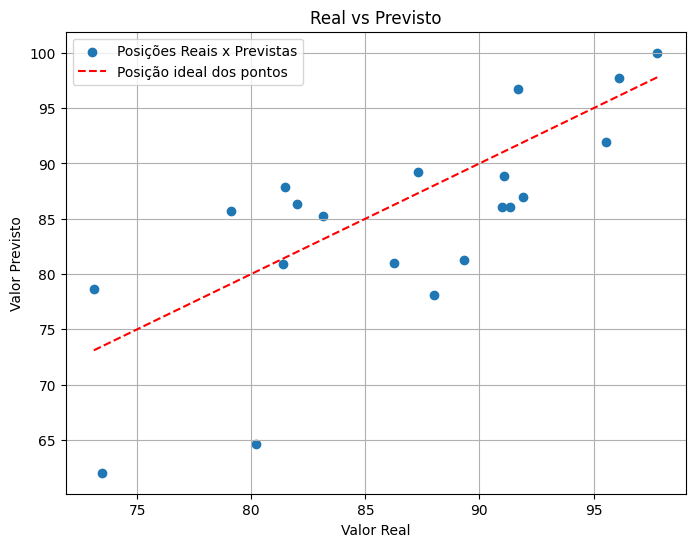


RMSE: 6.4545
MAE: 5.3728
R²: 0.1328


In [17]:
#@title 4.1.1 - Visualização do modelo linear (plot 2d)
plt.figure(figsize=(8,6))

plt.scatter(y_test, y_pred, label='Posições Reais x Previstas')

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    'r--', label='Posição ideal dos pontos'
)

plt.xlabel("Valor Real")
plt.ylabel("Valor Previsto")
plt.title("Real vs Previsto")

plt.grid(True)
plt.legend()
plt.show()
print(f"\nRMSE: {base_rmse:.4f}")
print(f"MAE: {base_mae:.4f}")
print(f"R²: {base_r2:.4f}")

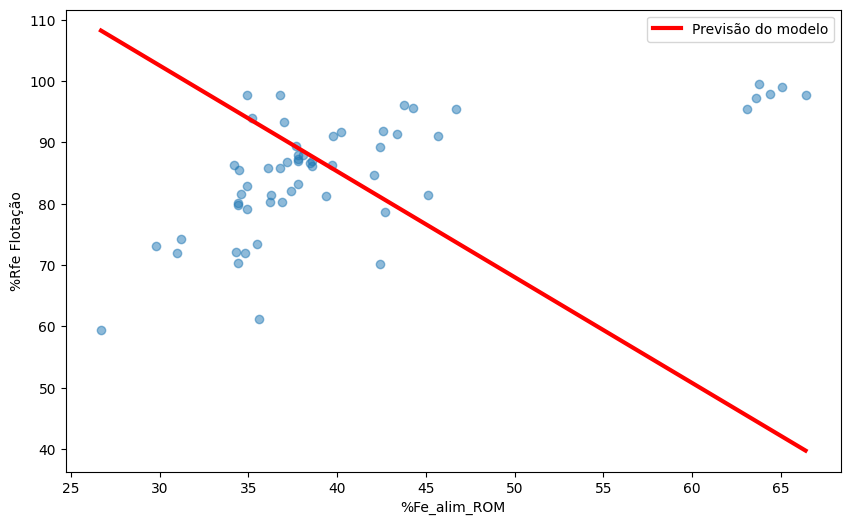

Coeficiente para a variável '%Fe_alim_ROM': -17.1961


In [18]:
#@title 4.1.2 - Visualização com respeito a uma variável
num_variavel_que_estamos_olhando_pro_modelo_linear = 0

x_grid = np.linspace(
    X[rom_cols[num_variavel_que_estamos_olhando_pro_modelo_linear]].min(),
    X[rom_cols[num_variavel_que_estamos_olhando_pro_modelo_linear]].max(),
    100
)

X_ref = pd.DataFrame(
    np.tile(X.mean().values, (100,1)),
    columns=rom_cols
)

X_ref[rom_cols[0]] = x_grid

X_ref_scaled = scaler.transform(X_ref)

y_grid = model.predict(X_ref_scaled)

plt.figure(figsize=(10,6))

plt.scatter(
    X[rom_cols[num_variavel_que_estamos_olhando_pro_modelo_linear]],
    y,
    alpha=0.5
)

plt.plot(x_grid, y_grid,
         color='red', linewidth=3,
         label='Previsão do modelo'
         )

plt.xlabel(rom_cols[0])
plt.ylabel(coluna_de_interesse)
plt.legend() # Display the legend
plt.show()

# Get and print the coefficient for the independent variable being plotted
var_index = rom_cols.index(rom_cols[num_variavel_que_estamos_olhando_pro_modelo_linear])
coefficient = model.coef_[var_index]
print(f"Coeficiente para a variável '{rom_cols[num_variavel_que_estamos_olhando_pro_modelo_linear]}': {coefficient:.4f}")

Modelos SVR

Treinamos 400 modelos SVR usando Hold-Out para comparar com o modelo base que é o modelo linear. Essa comparação foi feita com as métricas R², MAE e RMSE para cada modelo.



---
Além disso, passamos a usar **pipelines** de pré-processamento para cada tipo de modelagem, a fim de simplificar o scaling das variáveis independentes e os cortes de treino e teste nos dados.

##4.2 - Modelo em Lasso

In [19]:
#@title 4.2.1 - Treinando vários modelos Lasso
#valores de alpha que serão testados
alphas_lasso = np.logspace(-3, 2, 100)
lasso = []
#pipelne para Lasso
pipelineL = Pipeline([
    ('scaler', StandardScaler()),
    ('lasso', Lasso(max_iter=100000))
])
for i, alpha in enumerate(alphas_lasso, start=1):
  pipelineL.set_params(lasso__alpha=alpha)
  #treinamento
  pipelineL.fit(X_train, y_train)
  #previsão
  y_pred_lasso = pipelineL.predict(X_test)
  #métricas
  rmse = np.sqrt(mean_squared_error(y_test, y_pred_lasso))
  mae = mean_absolute_error(y_test, y_pred_lasso)
  r2 = r2_score(y_test, y_pred_lasso)
  lasso.append({
      'ID': i,
      'Modelo': 'Lasso',
      'Alpha': alpha,
      'R2': r2,
      'MAE': mae,
      'RMSE': rmse
  })
#Df
df_modelos_lasso = pd.DataFrame(lasso)
df_modelos_lasso = df_modelos_lasso.sort_values(
    by='R2',
    ascending=False
).reset_index(drop=True)
print("Melhores resultados do Lasso:")
display(
    df_modelos_lasso.head(20).style.format({
        'Alpha': '{:.5f}',
        'R2': '{:.4f}',
        'MAE': '{:.4f}',
        'RMSE': '{:.4f}'
    }).apply(
        lambda linha: destacar_linhas(linha, [0]),
        axis=1
    )
)

Melhores resultados do Lasso:


,ID,Modelo,Alpha,R2,MAE,RMSE
0,55,Lasso,0.53367,0.6601,3.3920,4.0412
1,56,Lasso,0.59948,0.6582,3.3757,4.0524
2,54,Lasso,0.47508,0.6524,3.4560,4.0865
3,57,Lasso,0.67342,0.6464,3.3804,4.1214
4,53,Lasso,0.42292,0.6406,3.5246,4.1552
5,58,Lasso,0.75646,0.6262,3.4119,4.2376
6,52,Lasso,0.37649,0.6262,3.5856,4.2378
7,51,Lasso,0.33516,0.6102,3.6459,4.3275
8,59,Lasso,0.84975,0.5958,3.4468,4.4065
9,50,Lasso,0.29836,0.5935,3.7105,4.4192


In [20]:
#@title 4.2.2 - Treinando o melhor Lasso
melhor_alpha_lasso = df_modelos_lasso.iloc[0]['Alpha']
print(f"Melhor alpha: {melhor_alpha_lasso:.5f}")
#treinando denovo o melhor Lasso
pipeline_lasso_chosen = Pipeline([
    ('scaler', StandardScaler()),
    ('lasso', Lasso(
        alpha=melhor_alpha_lasso,
        max_iter=100000
    ))
])
pipeline_lasso_chosen.fit(X_train, y_train)
y_pred_l_chosen = pipeline_lasso_chosen.predict(X_test)
#métricas
lasso_rmse = np.sqrt(
    mean_squared_error(y_test, y_pred_l_chosen)
)
lasso_mae = mean_absolute_error(
    y_test,
    y_pred_l_chosen
)
lasso_r2 = r2_score(
    y_test,
    y_pred_l_chosen
)
print(f"RMSE: {lasso_rmse:.4f}")
print(f"MAE: {lasso_mae:.4f}")
print(f"R²: {lasso_r2:.4f}")

Melhor alpha: 0.53367
RMSE: 4.0412
MAE: 3.3920
R²: 0.6601


In [21]:
#@title 4.2.3 - Gerando a equação do melhor Lasso
scaler_lasso = pipeline_lasso_chosen.named_steps['scaler']
modelo_lasso = pipeline_lasso_chosen.named_steps['lasso']
#Coeficientes na escala padronizada
coeficientes_padronizados_lasso = modelo_lasso.coef_
#Convertendo para a escala original das variáveis
coeficientes_originais_lasso = (
    coeficientes_padronizados_lasso / scaler_lasso.scale_
)
# Convertendo o intercepto para a escala original
intercepto_original_lasso = (
    modelo_lasso.intercept_
    - np.sum(
        coeficientes_padronizados_lasso
        * scaler_lasso.mean_
        / scaler_lasso.scale_
    )
)
print(f"Intercepto: {intercepto_original_lasso:.6f}\n")
print("Coeficientes do modelo Lasso:")
for variavel, coeficiente in zip(
    rom_cols,
    coeficientes_originais_lasso
):
    print(f"{variavel}: {coeficiente:.6f}")
#imprimir a equação
equacao_lasso = f"{coluna_de_interesse} = {intercepto_original_lasso:.6f}"
for variavel, coeficiente in zip(
    rom_cols,
    coeficientes_originais_lasso
):
    sinal = "+" if coeficiente >= 0 else "-"
    equacao_lasso += (
        f" {sinal} {abs(coeficiente):.6f}"
        f"*({variavel})"
    )
print("\nEquação do modelo Lasso:")
print(equacao_lasso)

Intercepto: 118.840628

Coeficientes do modelo Lasso:
%Fe_alim_ROM: 0.000000
%Al2O3_alim_ROM: -7.221702
%SiO2_alim_ROM: -0.561771
%P_alim_ROM: 5.702546
%Mn_alim_ROM: -8.175862
%TiO2_alim_ROM: -0.000000
%CaO_alim_ROM: -15.786637
%MgO_alim_ROM: -54.205518
PPC alim_ROM: 0.000000

Equação do modelo Lasso:
%Rfe Flotação = 118.840628 + 0.000000*(%Fe_alim_ROM) - 7.221702*(%Al2O3_alim_ROM) - 0.561771*(%SiO2_alim_ROM) + 5.702546*(%P_alim_ROM) - 8.175862*(%Mn_alim_ROM) + 0.000000*(%TiO2_alim_ROM) - 15.786637*(%CaO_alim_ROM) - 54.205518*(%MgO_alim_ROM) + 0.000000*(PPC alim_ROM)


##4.3 - Modelo em Ridge

In [22]:
#@title 4.3.1 - Treinando vários modelos Ridge
#valores de alpha que serão testados
alphas_ridge = np.logspace(-3, 2, 100)
ridge = []
#pipelne para Lasso
pipelineR = Pipeline([
    ('scaler', StandardScaler()),
    ('ridge', Ridge(max_iter=100000))
])
for i, alpha in enumerate(alphas_ridge, start=1):
    # Alterando o alpha do Ridge
    pipelineR.set_params(ridge__alpha=alpha)
    # Treinamento
    pipelineR.fit(X_train, y_train)
    # Previsão
    y_pred_ridge = pipelineR.predict(X_test)
    # Métricas
    rmse = np.sqrt(mean_squared_error(y_test, y_pred_ridge))
    mae = mean_absolute_error(y_test, y_pred_ridge)
    r2 = r2_score(y_test, y_pred_ridge)
    ridge.append({
        'ID': i,
        'Modelo': 'Ridge',
        'Alpha': alpha,
        'R2': r2,
        'MAE': mae,
        'RMSE': rmse
    })
#Df
df_modelos_ridge = pd.DataFrame(ridge)
df_modelos_ridge = df_modelos_ridge.sort_values(
    by='R2',
    ascending=False
).reset_index(drop=True)
print("Melhores resultados do Ridge:")
display(
    df_modelos_ridge.head(20).style.format({
        'Alpha': '{:.5f}',
        'R2': '{:.4f}',
        'MAE': '{:.4f}',
        'RMSE': '{:.4f}'
    }).apply(
        lambda linha: destacar_linhas(linha, [0]),
        axis=1
    )
)

Melhores resultados do Ridge:


,ID,Modelo,Alpha,R2,MAE,RMSE
0,78,Ridge,7.74264,0.5969,3.7789,4.4008
1,77,Ridge,6.89261,0.5967,3.7583,4.4019
2,79,Ridge,8.69749,0.5949,3.8009,4.4114
3,76,Ridge,6.13591,0.5942,3.7390,4.4154
4,80,Ridge,9.77010,0.5909,3.8243,4.4330
5,75,Ridge,5.46228,0.5894,3.7285,4.4414
6,81,Ridge,10.97499,0.5851,3.8492,4.4645
7,74,Ridge,4.86260,0.5822,3.7280,4.4799
8,82,Ridge,12.32847,0.5776,3.8757,4.5048
9,73,Ridge,4.32876,0.5728,3.7280,4.5304


In [23]:
#@title 4.3.2 - Treinando o melhor Ridge
melhor_alpha_ridge = df_modelos_ridge.iloc[0]['Alpha']
print(f"Melhor alpha: {melhor_alpha_ridge:.5f}")
#treinando denovo o melhor Ridge
pipeline_ridge_chosen = Pipeline([
    ('scaler', StandardScaler()),
    ('ridge', Ridge(alpha=melhor_alpha_ridge))
])
pipeline_ridge_chosen.fit(X_train, y_train)
y_pred_r_chosen = pipeline_ridge_chosen.predict(X_test)
#métricas
ridge_rmse = np.sqrt(
    mean_squared_error(y_test, y_pred_r_chosen)
)
ridge_mae = mean_absolute_error(
    y_test,
    y_pred_r_chosen
)
ridge_r2 = r2_score(
    y_test,
    y_pred_r_chosen
)
print(f"RMSE: {ridge_rmse:.4f}")
print(f"MAE: {ridge_mae:.4f}")
print(f"R²: {ridge_r2:.4f}")

Melhor alpha: 7.74264
RMSE: 4.4008
MAE: 3.7789
R²: 0.5969


In [24]:
#@title 4.3.3 - Gerando a equação do melhor Ridge
scaler_ridge = pipeline_ridge_chosen.named_steps['scaler']
modelo_ridge = pipeline_ridge_chosen.named_steps['ridge']
#coeficientes na escala padronizada
coeficientes_padronizados_ridge = modelo_ridge.coef_
#Convertendo para a escala original das variáveis
coeficientes_originais_ridge = (
    modelo_ridge.coef_ / scaler_ridge.scale_
)
intercepto_original_ridge = (
    modelo_ridge.intercept_
    - np.sum(
        modelo_ridge.coef_
        * scaler_ridge.mean_
        / scaler_ridge.scale_
    )
)
print(f"Intercepto: {intercepto_original_ridge:.6f}\n")
equacao_ridge = (
    f"{coluna_de_interesse} = "
    f"{intercepto_original_ridge:.6f}"
)
for variavel, coeficiente in zip(
    rom_cols,
    coeficientes_originais_ridge
):
    sinal = "+" if coeficiente >= 0 else "-"
    equacao_ridge += (
        f" {sinal} {abs(coeficiente):.6f}"
        f"*({variavel})"
    )
print("Equação do modelo Ridge:\n")
print(equacao_ridge)

Intercepto: 91.991348

Equação do modelo Ridge:

%Rfe Flotação = 91.991348 + 0.295382*(%Fe_alim_ROM) - 5.112837*(%Al2O3_alim_ROM) - 0.199333*(%SiO2_alim_ROM) + 58.605157*(%P_alim_ROM) - 21.302647*(%Mn_alim_ROM) - 22.091460*(%TiO2_alim_ROM) - 34.550320*(%CaO_alim_ROM) - 67.339547*(%MgO_alim_ROM) + 1.009654*(PPC alim_ROM)


##4.4 - Modelo em Elastic Net

In [25]:
#@title 4.4.1 - Treinando os modelos Elastic Net
Elastic_Net = []
alphas = np.logspace(-3, 2, 50)
l1_ratios = np.linspace(0.1, 0.9, 10)
# Pipeline para ElasticNet
pipelineEN = Pipeline([
    ('scaler', StandardScaler()),
    ('en', ElasticNet(random_state=42, max_iter=10000))
])
i = 1
for a in alphas:
    for l1 in l1_ratios:
        pipelineEN.set_params(en__alpha=a, en__l1_ratio=l1)
        pipelineEN.fit(X_train, y_train)
        y_pred_en = pipelineEN.predict(X_test)
        Elastic_Net.append({
            'ID': i,
            'Modelo': 'ElasticNet',
            'Alpha': a,
            'L1_Ratio': l1,
            'R2': r2_score(y_test, y_pred_en),
            'MAE': mean_absolute_error(y_test, y_pred_en),
            'RMSE': np.sqrt(mean_squared_error(y_test, y_pred_en))
        })
        i += 1
#organizando os resultados
df_modelosEN = pd.DataFrame(Elastic_Net)
df_modelosEN = df_modelosEN.sort_values(
    by='R2',
    ascending=False
).reset_index(drop=True)
print("Melhores resultados ElasticNet:")
display(
    df_modelosEN.head(10).style.format({
    'Alpha': '{:.4f}',
    'L1_Ratio': '{:.2f}',
    'R2': '{:.4f}',
    'MAE': '{:.4f}',
    'RMSE': '{:.4f}'
}).apply(
        lambda linha: destacar_linhas(
            linha,
            [0]
        ),
        axis=1
    )
)

Melhores resultados ElasticNet:


,ID,Modelo,Alpha,L1_Ratio,R2,MAE,RMSE
0,270,ElasticNet,0.4498,0.90,0.6337,3.6293,4.1950
1,280,ElasticNet,0.5690,0.90,0.6330,3.5507,4.1989
2,269,ElasticNet,0.4498,0.81,0.6223,3.6728,4.2598
3,259,ElasticNet,0.3556,0.81,0.6207,3.7022,4.2690
4,260,ElasticNet,0.3556,0.90,0.6195,3.7048,4.2755
5,258,ElasticNet,0.3556,0.72,0.6154,3.7232,4.2984
6,279,ElasticNet,0.5690,0.81,0.6137,3.6307,4.3082
7,290,ElasticNet,0.7197,0.90,0.6112,3.4735,4.3221
8,248,ElasticNet,0.2812,0.72,0.6108,3.6880,4.3238
9,247,ElasticNet,0.2812,0.63,0.6103,3.7107,4.3269


In [26]:
#@title 4.4.2 - Treinando denovo o melhor modelo Elastic Net
# Pegando a primeira linha do DataFrame
melhor_elasticnet = df_modelosEN.iloc[0]
# Extraindo os melhores hiperparâmetros
melhor_alpha_elasticnet = melhor_elasticnet[
    'Alpha'
]

melhor_l1_ratio_elasticnet = melhor_elasticnet[
    'L1_Ratio'
]

print(
    f"Melhor alpha: "
    f"{melhor_alpha_elasticnet:.5f}"
)

print(
    f"Melhor l1_ratio: "
    f"{melhor_l1_ratio_elasticnet:.2f}"
)

# Criando novamente o melhor modelo
pipeline_elasticnet_chosen = Pipeline([
    ('scaler', StandardScaler()),
    (
        'elasticnet',
        ElasticNet(
            alpha=melhor_alpha_elasticnet,
            l1_ratio=melhor_l1_ratio_elasticnet,
            max_iter=100000,
            random_state=42
        )
    )
])
pipeline_elasticnet_chosen.fit(X_train, y_train)
y_pred_en_chosen = (pipeline_elasticnet_chosen.predict(X_test))
# Métricas
elasticnet_rmse = np.sqrt(mean_squared_error(y_test, y_pred_en_chosen))
elasticnet_mae = mean_absolute_error(y_test, y_pred_en_chosen)
elasticnet_r2 = r2_score(y_test, y_pred_en_chosen)
print("\nMétricas do melhor Elastic Net:")
print(f"RMSE: {elasticnet_rmse:.4f}")
print(f"MAE: {elasticnet_mae:.4f}")
print(f"R²: {elasticnet_r2:.4f}")

Melhor alpha: 0.44984
Melhor l1_ratio: 0.90

Métricas do melhor Elastic Net:
RMSE: 4.1950
MAE: 3.6293
R²: 0.6337


In [27]:
#@title 4.4.3 - Gerando equação do melhor modelo Elastic Net
# Recuperando o scaler e o modelo
scaler_elasticnet = (
    pipeline_elasticnet_chosen.named_steps[
        'scaler'
    ]
)
modelo_elasticnet = (
    pipeline_elasticnet_chosen.named_steps[
        'elasticnet'
    ]
)
# Coeficientes na escala padronizada
coeficientes_padronizados_elasticnet = (
    modelo_elasticnet.coef_
)
# Convertendo para a escala original
coeficientes_originais_elasticnet = (
    coeficientes_padronizados_elasticnet
    / scaler_elasticnet.scale_
)
# Convertendo o intercepto
intercepto_original_elasticnet = (
    modelo_elasticnet.intercept_
    - np.sum(
        coeficientes_padronizados_elasticnet
        * scaler_elasticnet.mean_
        / scaler_elasticnet.scale_
    )
)
print(f"Intercepto: "f"{intercepto_original_elasticnet:.6f}\n")
print("Coeficientes do modelo Elastic Net:")
for variavel, coeficiente in zip(
    rom_cols,
    coeficientes_originais_elasticnet
):
    print(f"{variavel}: "f"{coeficiente:.6f}")
# Montando a equação
equacao_elasticnet = (f"{coluna_de_interesse} = "f"{intercepto_original_elasticnet:.6f}")
for variavel, coeficiente in zip(
    rom_cols,
    coeficientes_originais_elasticnet
):
    sinal = "+" if coeficiente >= 0 else "-"
    equacao_elasticnet += (
        f" {sinal} "
        f"{abs(coeficiente):.6f}"
        f"*({variavel})"
    )
print("\nEquação do modelo Elastic Net:")
print(equacao_elasticnet)

Intercepto: 94.307541

Coeficientes do modelo Elastic Net:
%Fe_alim_ROM: 0.322044
%Al2O3_alim_ROM: -6.515742
%SiO2_alim_ROM: -0.284494
%P_alim_ROM: 33.809374
%Mn_alim_ROM: -13.010935
%TiO2_alim_ROM: -0.000000
%CaO_alim_ROM: -24.922410
%MgO_alim_ROM: -59.660287
PPC alim_ROM: 0.000000

Equação do modelo Elastic Net:
%Rfe Flotação = 94.307541 + 0.322044*(%Fe_alim_ROM) - 6.515742*(%Al2O3_alim_ROM) - 0.284494*(%SiO2_alim_ROM) + 33.809374*(%P_alim_ROM) - 13.010935*(%Mn_alim_ROM) + 0.000000*(%TiO2_alim_ROM) - 24.922410*(%CaO_alim_ROM) - 59.660287*(%MgO_alim_ROM) + 0.000000*(PPC alim_ROM)


#**5 - Modelos que não geram equações**

##5.1 - Modelos SVR

In [28]:
#@title 5.1.1 - Variação do Epsilon e C
list_modelosSVR = []
valoresC = np.linspace(0.01, 20, 20)
valoresEpsilon = np.linspace(0.1, 5, 20)
#implementação do pipeline
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('svr', SVR(kernel='rbf'))
])
i = 1;
for C in valoresC:
  for Epsilon in valoresEpsilon:

    pipeline.set_params(
        svr__C=C,
        svr__epsilon=Epsilon
    )
    pipeline.fit(X_train, y_train)
    y_pred = pipeline.predict(X_test)
    list_modelosSVR.append({
        'ID' : i,
        'Modelo': 'SVR',
        'C': C,
        'Epsilon': Epsilon,
        'R2': r2_score(y_test, y_pred),
        'MAE': mean_absolute_error(y_test, y_pred),
        'RMSE': np.sqrt(mean_squared_error(y_test, y_pred))
    })
    i=i+1;

In [29]:
#@title 5.1.2 - Tabela dos melhores SVR
df_modelosSVR = pd.DataFrame(list_modelosSVR)
df_modelosSVR = df_modelosSVR.sort_values(by='R2', ascending=False)

#adicionando o modelo base no DataFrame
dict_modeloBase = {
        'ID' : 0,
        'Modelo': 'Base',
        'C': np.nan,
        'Epsilon': np.nan,
        'R2': base_r2,
        'MAE': base_mae,
        'RMSE': base_rmse
}
df_modelosSVR = pd.concat([pd.DataFrame([dict_modeloBase]), df_modelosSVR])

display(df_modelosSVR.head(30).style.format({
    'C': '{:.2f}',
    'Epsilon': '{:.2f}',
    'R2': '{:.4f}',
    'MAE': '{:.4f}',
    'RMSE': '{:.4f}'
}).apply(lambda r: destacar_linhas(r, [0]), axis=1))

###Código abaixo em desuso
###Primeiro estávamos manipulando a list diretamente e então transformando o final em DataFrame,
###mas percebemos que é interessante manter todos os modelos no Df para revisão posterior com o
###display do Pandas. Portanto estamos transformando a list em Df logo após gerar os modelos agora.

# list_modelosSVR = sorted(list_modelosSVR, key=lambda x: x['R2'], reverse=True)
#reverse indica se a organização será crescente (False) ou descrescente (True);
#o parâmetro key especifica uma função a ser chamada antes começar as comparações;
#lambda x: x['R2'] é uma função anônima que leva um argumento (x), que é cada dicionário na lista de dicionário 'list_modelosSVR' e retorna o valor associado com a chave 'R2' desse dicionário;
#então, o sorted() funciona com base no valor numérico de 'R2' pra cada modelo na lista.

# # inserindo o modelo base no 0 para comparação
# list_modelosSVR.insert(0, {
#     'Modelo': 'Linear',
#     'C': np.nan,
#     'Epsilon': np.nan,
#     'R2': base_r2,
#     'MAE': base_mae,
#     'RMSE': base_rmse
# })

,ID,Modelo,C,Epsilon,R2,MAE,RMSE
0,0,Base,nan,nan,0.1328,5.3728,6.4545
380,381,SVR,20.00,0.10,0.5057,4.1370,4.8731
360,361,SVR,18.95,0.10,0.5012,4.1780,4.8953
340,341,SVR,17.90,0.10,0.4947,4.2402,4.9271
381,382,SVR,20.00,0.36,0.4938,4.1848,4.9313
361,362,SVR,18.95,0.36,0.4896,4.2285,4.9520
320,321,SVR,16.84,0.10,0.4863,4.3239,4.9678
300,301,SVR,15.79,0.10,0.4854,4.3597,4.9723
280,281,SVR,14.74,0.10,0.4843,4.3915,4.9774
341,342,SVR,17.90,0.36,0.4840,4.2685,4.9787


Escolhemos o SVR avaliado como primeiro lugar em R2, o **249º criado** usando a pipeline (ID 249),\
com <u>*C=12.64*</u> e <u>*Epsilon=2.16*</u>.

Por termos separado treino e teste, não é preciso ter medo de escolher um modelo que sofra de overfitting. É claro que as outras técnicas mais computacionalmente taxantes de split diminuiriam ainda mais a possibilidade de overfit, mas não faz diferença procurar na tabela acima um modelo que "não tenha R2 alto demais e possa overfittar".

In [30]:
#@title 5.1.3 - Selecionando somente os modelos SVR
df_apenas_SVR = df_modelosSVR[
    df_modelosSVR['Modelo'] == 'SVR'
]
# Pegando automaticamente o SVR com maior R²
svr_chosen = (
    df_apenas_SVR
    .sort_values(
        by='R2',
        ascending=False
    )
    .head(1)
)
svr_chosen_id = int(
    svr_chosen['ID'].iloc[0]
)
print(
    f"Melhor modelo SVR: "
    f"ID {svr_chosen_id}"
)

Melhor modelo SVR: ID 381


In [31]:
#@title 5.1.4 - Comparação do modelo Base com os melhores SVR
#Destacando modelo base da tabela (ID 0)
df_base_model = df_modelosSVR[df_modelosSVR['ID'] == 0]

# Get all SVR models, excluding the chosen one by its 'ID'
todosSVR_exceto_chosen = df_modelosSVR[
    (df_modelosSVR['Modelo'] == 'SVR') &
    (df_modelosSVR['ID'] != svr_chosen_id)
]

#Organizar por R2 e selecionar o top 3 dos melhores SVR da lista filtrada
top3_modelosSVR = todosSVR_exceto_chosen.sort_values(by='R2', ascending=False).head(3)

# Concatenação na ordem: Base, Chosen SVR, Top 3 outros SVRs
df_comparacao = pd.concat([df_base_model, svr_chosen, top3_modelosSVR])

# Reset index for consistent highlighting, but do not add the old index as a column
df_comparacao = df_comparacao.reset_index(drop=True)

# Display the comparison DataFrame with highlighting for the base model (new index 0)
# and the chosen SVR model (new index 1)
display(df_comparacao.style.format({
    'C': '{:.2f}',
    'Epsilon': '{:.2f}',
    'R2': '{:.4f}',
    'MAE': '{:.4f}',
    'RMSE': '{:.4f}'
}).apply(lambda r: destacar_linhas(r, [0, 1]), axis=1))

#--Comparando as métricas do SVR escolhido com as do base
svr_r2 = svr_chosen['R2'].iloc[0]
svr_mae = svr_chosen['MAE'].iloc[0]
svr_rmse = svr_chosen['RMSE'].iloc[0]

metricas = ['R2', 'MAE', 'RMSE']
base_metricas = {'R2': base_r2, 'MAE': base_mae, 'RMSE': base_rmse}
svr_metricas = {'R2': svr_r2, 'MAE': svr_mae, 'RMSE': svr_rmse}

for metrica_nome in metricas:
    base_val = base_metricas[metrica_nome]
    svr_val = svr_metricas[metrica_nome]

    if pd.isna(svr_val) or pd.isna(base_val) or base_val == 0:
        print(f"Não é possível comparar {metrica_nome} (valores ausentes ou divisão por zero).")
    else:
        if metrica_nome == 'R2':
            # Maior é melhor pra R2
            change_percent = ((svr_val - base_val) / base_val) * 100
            if change_percent >= 0:
                print(f"{metrica_nome}: Modelo escolhido (ID {svr_chosen_id}) é {change_percent:.2f}% melhor que o modelo base")
            else:
                print(f"{metrica_nome}: Modelo escolhido (ID {svr_chosen_id}) é {-change_percent:.2f}% pior que o modelo base")
        else:
            # Menor é melhor pra MAE e RMSE
            change_percent = ((base_val - svr_val) / base_val) * 100
            if change_percent >= 0:
                print(f"{metrica_nome}: Modelo escolhido (ID {svr_chosen_id}) é {change_percent:.2f}% melhor que o modelo base")
            else:
                print(f"{metrica_nome}: Modelo escolhido (ID {svr_chosen_id}) é {-change_percent:.2f}% pior que o modelo base")
#--Comparando as métricas do SVR escolhido com as do base

,ID,Modelo,C,Epsilon,R2,MAE,RMSE
0,0,Base,nan,nan,0.1328,5.3728,6.4545
1,381,SVR,20.00,0.10,0.5057,4.1370,4.8731
2,361,SVR,18.95,0.10,0.5012,4.1780,4.8953
3,341,SVR,17.90,0.10,0.4947,4.2402,4.9271
4,382,SVR,20.00,0.36,0.4938,4.1848,4.9313


R2: Modelo escolhido (ID 381) é 280.74% melhor que o modelo base
MAE: Modelo escolhido (ID 381) é 23.00% melhor que o modelo base
RMSE: Modelo escolhido (ID 381) é 24.50% melhor que o modelo base


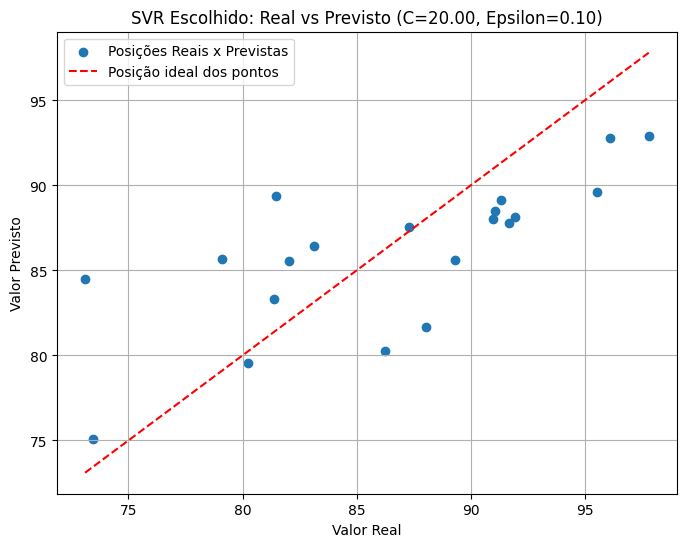

In [32]:
#@title 5.1.5 - Plotando o SVR escolhido
# Plotando SVR escolhido: Real vs Previsto (similar ao modelo linear)

# Recriar o pipeline para o SVR escolhido com seus melhores parâmetros
pipeline_svr_chosen = Pipeline([
    ('scaler', StandardScaler()),
    ('svr', SVR(kernel='rbf', C=svr_chosen['C'].iloc[0], epsilon=svr_chosen['Epsilon'].iloc[0]))
])

# Ajuste do pipeline aos dados de treinamento.
pipeline_svr_chosen.fit(X_train, y_train)

# Fazendo as previsões
y_pred_svr_chosen = pipeline_svr_chosen.predict(X_test)

plt.figure(figsize=(8,6))

# Gráfico de dispersão dos valores reais versus previstos no conjunto de teste
plt.scatter(y_test, y_pred_svr_chosen, label='Posições Reais x Previstas')

# plot da linha ideal y=x (onde o valor previsto é igual ao real)
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    'r--', label='Posição ideal dos pontos'
)

plt.xlabel("Valor Real")
plt.ylabel("Valor Previsto")
plt.title(f"SVR Escolhido: Real vs Previsto (C={svr_chosen['C'].iloc[0]:.2f}, Epsilon={svr_chosen['Epsilon'].iloc[0]:.2f})")

plt.grid(True)
plt.legend()
plt.show()

##5.2 - Modelo de Decision tree

In [33]:
#@title 5.2.1 - Treinando os modelos de DT
#pipeline
pipeline_dt = Pipeline([
    ('dt', DecisionTreeRegressor(random_state=42))
])
#hiperparâmetros
Decision_Tree = []
max_depths = [3, 5, 7, 10, None]
min_samples_splits = [2, 5, 10]
min_samples_leafs = [1, 2, 4]
i = 1
for depth in max_depths:
    for split in min_samples_splits:
        for leaf in min_samples_leafs:
            # Pipeline
            pipeline_dt = Pipeline([
                ('dt', DecisionTreeRegressor(
                    random_state=42,
                    max_depth=depth,
                    min_samples_split=split,
                    min_samples_leaf=leaf
                ))
            ])
            # Treinamento
            pipeline_dt.fit(X_train, y_train)
            # Previsão
            y_pred_dt = pipeline_dt.predict(X_test)
            # Métricas
            rmse = np.sqrt(mean_squared_error(y_test, y_pred_dt))
            mae = mean_absolute_error(y_test, y_pred_dt)
            r2 = r2_score(y_test, y_pred_dt)
            Decision_Tree.append({
                "Teste": i,
                "Max_Depth": depth,
                "Min_Samples_Split": split,
                "Min_Samples_Leaf": leaf,
                "RMSE": rmse,
                "MAE": mae,
                "R2": r2
            })
            i += 1

In [34]:
#@title 5.2.2 - Organizando os resultados
df_modelosDT = pd.DataFrame(Decision_Tree)
df_modelosDT = df_modelosDT.sort_values(
    by='R2',
    ascending=False
).reset_index(drop=True)
print("Melhores resultados Decision Tree:")
display(
    df_modelosDT.head(10).style.format({
    'max_depth': '{}',
    'min_samples_split': '{}',
    'min_samples_leaf': '{}',
    'R²': '{:.4f}',
    'MAE': '{:.4f}',
    'RMSE': '{:.4f}'
}).apply(
    lambda linha: destacar_linhas(linha, [0]),
        axis=1
    )
)

Melhores resultados Decision Tree:


,Teste,Max_Depth,Min_Samples_Split,Min_Samples_Leaf,RMSE,MAE,R2
0,3,3.000000,2,4,9.8179,8.4614,-1.006427
1,6,3.000000,5,4,9.8179,8.4614,-1.006427
2,9,3.000000,10,4,9.9490,8.7322,-1.060376
3,12,5.000000,2,4,9.9681,8.7588,-1.068279
4,15,5.000000,5,4,9.9681,8.7588,-1.068279
5,30,10.000000,2,4,9.9681,8.7588,-1.068279
6,33,10.000000,5,4,9.9681,8.7588,-1.068279
7,42,nan,5,4,9.9681,8.7588,-1.068279
8,39,nan,2,4,9.9681,8.7588,-1.068279
9,21,7.000000,2,4,9.9681,8.7588,-1.068279


In [35]:
#@title 5.2.3 - Treinando o melhor modelo DT denovo
melhor_DT = df_modelosDT.iloc[0]
# O Pandas transforma None em NaN dentro do DataFrame
if pd.isna(melhor_DT['Max_Depth']):
    melhor_max_depth_DT = None
else:
    melhor_max_depth_DT = int(
        melhor_DT['Max_Depth']
    )
melhor_min_samples_split_DT = int(
    melhor_DT['Min_Samples_Split']
)
melhor_min_samples_leaf_DT = int(
    melhor_DT['Min_Samples_Leaf']
)
print(
    f"Melhor max_depth: "
    f"{melhor_max_depth_DT}"
)
print(
    f"Melhor min_samples_split: "
    f"{melhor_min_samples_split_DT}"
)
print(
    f"Melhor min_samples_leaf: "
    f"{melhor_min_samples_leaf_DT}"
)
# Criando novamente o melhor modelo
pipeline_DT_chosen = Pipeline([
    (
        'decisiontree',
        DecisionTreeRegressor(
            max_depth=melhor_max_depth_DT,
            min_samples_split=melhor_min_samples_split_DT,
            min_samples_leaf=melhor_min_samples_leaf_DT,
            random_state=42
        )
    )
])
# Treinamento
pipeline_DT_chosen.fit(
    X_train,
    y_train
)
# Previsão
y_pred_dt_chosen = pipeline_DT_chosen.predict(
    X_test
)
# Métricas finais
dt_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        y_pred_dt_chosen
    )
)
dt_mae = mean_absolute_error(
    y_test,
    y_pred_dt_chosen
)
dt_r2 = r2_score(
    y_test,
    y_pred_dt_chosen
)
print("\nMétricas da melhor Decision Tree:")
print(f"RMSE: {dt_rmse:.4f}")
print(f"MAE: {dt_mae:.4f}")
print(f"R²: {dt_r2:.4f}")

Melhor max_depth: 3
Melhor min_samples_split: 2
Melhor min_samples_leaf: 4

Métricas da melhor Decision Tree:
RMSE: 9.8179
MAE: 8.4614
R²: -1.0064


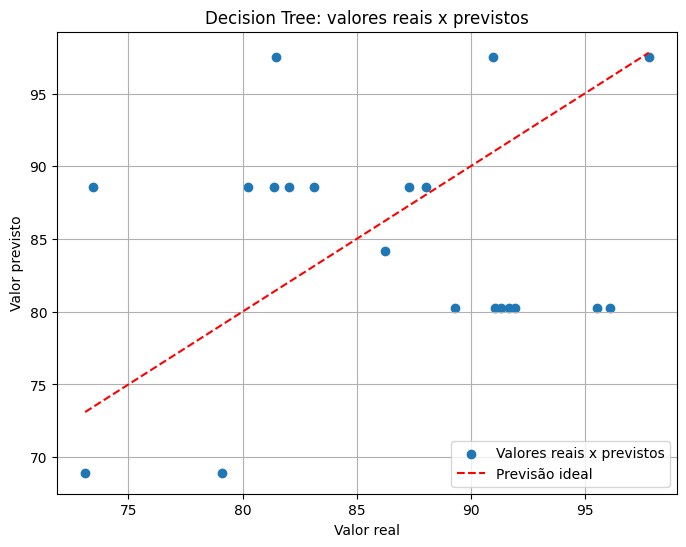

RMSE: 9.8179
MAE: 8.4614
R²: -1.0064


In [36]:
#@title 5.2.4 - Visualização da melhor DT
plt.figure(figsize=(8, 6))
plt.scatter(
    y_test,
    y_pred_dt_chosen,
    label='Valores reais x previstos'
)
# Linha ideal: valor previsto igual ao valor real
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    'r--',
    label='Previsão ideal'
)
plt.xlabel("Valor real")
plt.ylabel("Valor previsto")
plt.title(
    "Decision Tree: valores reais x previstos"
)
plt.grid(True)
plt.legend()
plt.show()
print(f"RMSE: {dt_rmse:.4f}")
print(f"MAE: {dt_mae:.4f}")
print(f"R²: {dt_r2:.4f}")

,Variável,Importância
0,%SiO2_alim_ROM,0.5144
1,%Fe_alim_ROM,0.2804
2,%TiO2_alim_ROM,0.1132
3,%P_alim_ROM,0.0920
4,%Al2O3_alim_ROM,0.0000
5,%Mn_alim_ROM,0.0000
6,%CaO_alim_ROM,0.0000
7,%MgO_alim_ROM,0.0000
8,PPC alim_ROM,0.0000


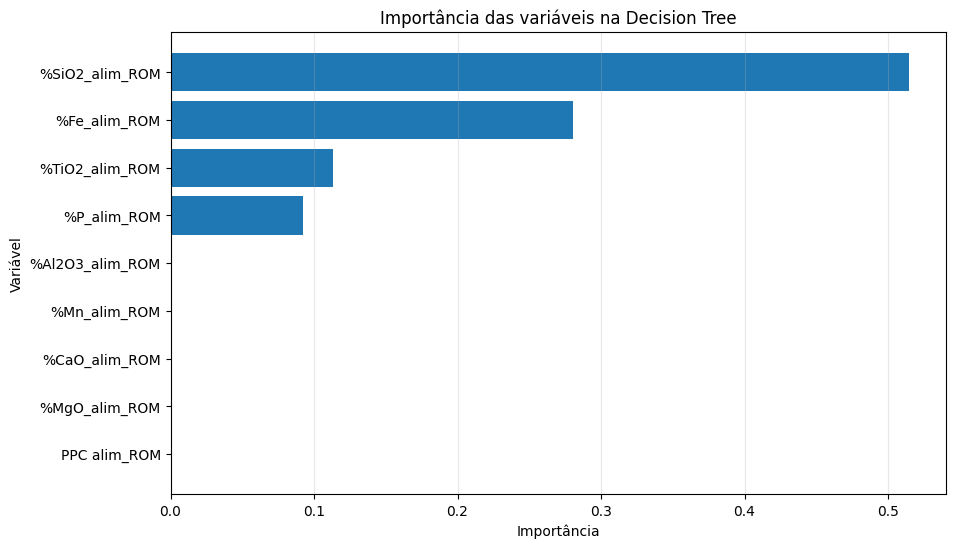

In [37]:
#@title 5.2.5 - Importância das variáveis no DT
modelo_DT = pipeline_DT_chosen.named_steps[
    'decisiontree'
]
df_importancias_DT = pd.DataFrame({
    'Variável': rom_cols,
    'Importância': modelo_DT.feature_importances_
})
df_importancias_DT = df_importancias_DT.sort_values(
    by='Importância',
    ascending=False
).reset_index(drop=True)
display(
    df_importancias_DT.style.format({
        'Importância': '{:.4f}'
    })
)
plt.figure(figsize=(10, 6))
plt.barh(
    df_importancias_DT['Variável'][::-1],
    df_importancias_DT['Importância'][::-1]
)
plt.xlabel("Importância")
plt.ylabel("Variável")
plt.title("Importância das variáveis na Decision Tree")
plt.grid(
    axis='x',
    alpha=0.3
)
plt.show()

##5.3 - Modelo de Random Forest

In [38]:
#@title 5.3.1 - Treinando os modelos de RF
#Hiperparâmetros que serão testados
RandomForest = []
RF_n_estimators_values = [50, 100, 200]
RF_max_depth_values = [10, 20, 30, None]
#pipeline do RF
pipeline_rf = Pipeline([
    # ('scaler', StandardScaler()),
    # scalers em CARTs são redundantes
    ('randomforest', RandomForestRegressor(random_state=42))
])
i = 1;
for n_est in RF_n_estimators_values:
  for m_depth in RF_max_depth_values:
    # Set parameters for the current iteration
    pipeline_rf.set_params(
        randomforest__n_estimators=n_est,
        randomforest__max_depth=m_depth
    )
    pipeline_rf.fit(X_train, y_train)
    y_pred_rf = pipeline_rf.predict(X_test)
    #métricas
    rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
    mae_rf = mean_absolute_error(y_test, y_pred_rf)
    r2_rf = r2_score(y_test, y_pred_rf)
    RandomForest.append({
        'ID': i,
        'Modelo': 'RandomForest',
        'R2': r2_rf,
        'MAE': mae_rf,
        'RMSE': rmse_rf,
        'Max_Depth': m_depth,
        'N_Estimators': n_est
    })
    i += 1;

In [39]:
#@title 5.3.2 - Organizando os resultados
df_modelosRF = pd.DataFrame(RandomForest)
df_modelosRF = df_modelosRF.sort_values(
    by='R2',
    ascending=False
).reset_index(drop=True)
print('Melhores resultados do Random Forest:')
display(
    df_modelosRF.head(20).style.format({
        'R2': '{:.4f}',
        'MAE': '{:.4f}',
        'RMSE': '{:.4f}',
        'N_Estimators': '{:.0f}',
        'Max_Depth': lambda valor:
            'None' if pd.isna(valor)
            else f'{valor:.0f}'
    }).apply(
        lambda linha: destacar_linhas(linha, [0]),
        axis=1
    )
)

Melhores resultados do Random Forest:


,ID,Modelo,R2,MAE,RMSE,Max_Depth,N_Estimators
0,5,RandomForest,0.1163,5.6868,6.5158,10,100
1,8,RandomForest,0.1130,5.6970,6.5277,None,100
2,6,RandomForest,0.1130,5.6970,6.5277,20,100
3,7,RandomForest,0.1130,5.6970,6.5277,30,100
4,9,RandomForest,0.0689,5.8608,6.6880,10,200
5,1,RandomForest,0.0649,5.8566,6.7026,10,50
6,11,RandomForest,0.0649,5.8666,6.7026,30,200
7,10,RandomForest,0.0649,5.8666,6.7026,20,200
8,12,RandomForest,0.0649,5.8666,6.7026,None,200
9,4,RandomForest,0.0579,5.8732,6.7275,None,50


In [40]:
#@title 5.3.3 - Treinando o melhor RF denovo
melhor_RF = df_modelosRF.iloc[0]
melhor_n_estimators_RF = int(
    melhor_RF['N_Estimators']
)
# O Pandas transforma None em NaN dentro do DataFrame
if pd.isna(melhor_RF['Max_Depth']):
  melhor_max_depth_RF = None
else:
  melhor_max_depth_RF = int(
      melhor_RF['Max_Depth']
  )
print(f"melhor número de árvores = " f"{melhor_n_estimators_RF}")
print(f"melhor max_depth = " f"{melhor_max_depth_RF}")
# Criando novamente o melhor modelo
pipeline_RF_chosen = Pipeline([
    (
        'randomforest',
        RandomForestRegressor(
            n_estimators=melhor_n_estimators_RF,
            max_depth=melhor_max_depth_RF,
            random_state=42,
            n_jobs=-1
        )
    )
])
# Treinamento
pipeline_RF_chosen.fit(
    X_train,
    y_train
)
# Previsão
y_pred_rf_chosen = pipeline_RF_chosen.predict(
    X_test
)
# Métricas
rf_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        y_pred_rf_chosen
    )
)
rf_mae = mean_absolute_error(
    y_test,
    y_pred_rf_chosen
)
rf_r2 = r2_score(
    y_test,
    y_pred_rf_chosen
)
print("\nMétricas do melhor Random Forest:")
print(f"RMSE: {rf_rmse:.4f}")
print(f"MAE: {rf_mae:.4f}")
print(f"R²: {rf_r2:.4f}")

melhor número de árvores = 100
melhor max_depth = 10

Métricas do melhor Random Forest:
RMSE: 6.5158
MAE: 5.6868
R²: 0.1163


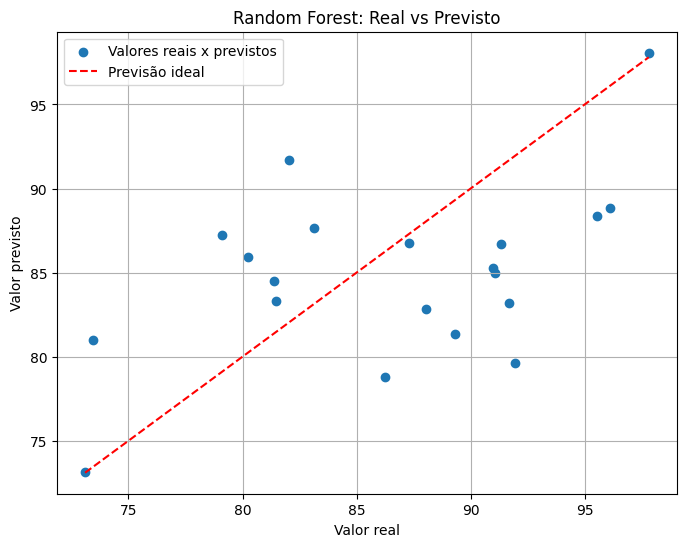

RMSE: 6.5158
MAE: 5.6868
R²: 0.1163


In [41]:
#@title 5.3.4 - Visualização do melhor modelo RF
plt.figure(figsize=(8,6))
plt.scatter(
    y_test,
    y_pred_rf_chosen,
    label='Valores reais x previstos'
)
# Linha ideal: valor previsto igual ao valor real
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    'r--',
    label='Previsão ideal'
)
plt.xlabel("Valor real")
plt.ylabel("Valor previsto")
plt.title(
    "Random Forest: Real vs Previsto"
)
plt.grid(True)
plt.legend()
plt.show()
print(f"RMSE: {rf_rmse:.4f}")
print(f"MAE: {rf_mae:.4f}")
print(f"R²: {rf_r2:.4f}")

In [42]:
#@title 5.3.5 - Comparação com o modelo linear
df_comparacaoRF = pd.DataFrame([
    {
        'Modelo': 'Linear',
        'N_Estimators': np.nan,
        'Max_Depth': np.nan,
        'R2': base_r2,
        'MAE': base_mae,
        'RMSE': base_rmse
    },
    {
        'Modelo': 'RandomForest',
        'N_Estimators': melhor_n_estimators_RF,
        'Max_Depth': melhor_max_depth_RF,
        'R2': rf_r2,
        'MAE': rf_mae,
        'RMSE': rf_rmse
    }
])
display(
    df_comparacaoRF.style.format({
        'N_Estimators': lambda valor:
            '-' if pd.isna(valor)
            else f'{valor:.0f}',
        'Max_Depth': lambda valor:
            '-' if pd.isna(valor)
            else f'{valor:.0f}',
        'R2': '{:.4f}',
        'MAE': '{:.4f}',
        'RMSE': '{:.4f}'
    }).apply(
        lambda linha: destacar_linhas(
            linha,
            [0, 1]
        ),
        axis=1
    )
)

,Modelo,N_Estimators,Max_Depth,R2,MAE,RMSE
0,Linear,-,-,0.1328,5.3728,6.4545
1,RandomForest,100,10,0.1163,5.6868,6.5158


In [43]:
#@title 5.3.6 - Importância das variáveis no RF
# Acessando o modelo dentro da pipeline
modelo_RF_chosen = (
    pipeline_RF_chosen
    .named_steps['randomforest']
)
df_importanciasRF = pd.DataFrame({
    'Variável': rom_cols,
    'Importância':
        modelo_RF_chosen.feature_importances_
})
df_importanciasRF = df_importanciasRF.sort_values(
    by='Importância',
    ascending=False
).reset_index(drop=True)
display(
    df_importanciasRF.style.format({
        'Importância': '{:.4f}'
    })
)
# Gráfico interativo
fig = px.bar(
    df_importanciasRF.sort_values(
        by='Importância',
        ascending=True
    ),
    x='Importância',
    y='Variável',
    orientation='h',
    title='Importância das variáveis no Random Forest'
)
fig.show()

,Variável,Importância
0,%Fe_alim_ROM,0.3169
1,%SiO2_alim_ROM,0.2547
2,%P_alim_ROM,0.1631
3,%Al2O3_alim_ROM,0.0709
4,%TiO2_alim_ROM,0.0510
5,%CaO_alim_ROM,0.0498
6,PPC alim_ROM,0.0430
7,%Mn_alim_ROM,0.0421
8,%MgO_alim_ROM,0.0085


##5.4 - Modelo de Gradient Boost

In [44]:
#@title 5.4.1 - Treinando os modelos de Gradient Boosting
Gradient_Boost = []

GB_n_estimators_values = np.linspace(290, 310, 4).astype(int) #the number of boosting stages that will be performed.
GB_max_depth_values = [6] #numero de nós
GB_learning_rate_values = [0.0025] #o quanto a contribuição de cada árvore diminui
GB_loss_types = ['squared_error', 'huber'] #padrão: squared_error
#huber é uma mistura de MSE (squared error) e erro absoluto

#pipeline do GB
pipeline_gb = Pipeline([
    # ('scaler', StandardScaler()), # Scalers em CARTs são redundantes
    ('gradientboosting', GradientBoostingRegressor(random_state=42))
])
i = 1;
for n_est in GB_n_estimators_values:
  for m_depth in GB_max_depth_values:
    for lr in GB_learning_rate_values:
      for loss_type in GB_loss_types:

        #parametros da iteracao atual
        pipeline_gb.set_params(
            gradientboosting__n_estimators=n_est,
            gradientboosting__max_depth=m_depth,
            gradientboosting__learning_rate=lr,
            gradientboosting__loss=loss_type
        )
        pipeline_gb.fit(X_train, y_train)
        y_pred_gb = pipeline_gb.predict(X_test)

        #métricas
        rmse_gb = np.sqrt(mean_squared_error(y_test, y_pred_gb))
        mae_gb = mean_absolute_error(y_test, y_pred_gb)
        r2_gb = r2_score(y_test, y_pred_gb)
        Gradient_Boost.append({
            'ID': i,
            'Modelo': 'GradientBoosting',
            'R2': r2_gb,
            'MAE': mae_gb,
            'RMSE': rmse_gb,
            'Max_Depth': m_depth,
            'N_Estimators': n_est,
            'Learning_Rate': lr,
            'Loss': loss_type
        })
        i += 1;

In [45]:
#@title 5.4.2 - Organizando os resultados
# Transformando em DataFrame e ordenando por R2
df_modelosGB = pd.DataFrame(Gradient_Boost).sort_values(by='R2', ascending=False).reset_index(drop=True)

print("Melhores resultados do Gradient Boosting:")
display(df_modelosGB.head(10).style.format({
    'R2': '{:.4f}',
    'MAE': '{:.4f}',
    'RMSE': '{:.4f}',
    'Max_Depth': '{}',
    'N_Estimators': '{}',
    'Learning_Rate': '{:.5f}',
    'Loss': '{}'
}).apply(lambda r: destacar_linhas(r, [0]), axis=1))

Melhores resultados do Gradient Boosting:


,ID,Modelo,R2,MAE,RMSE,Max_Depth,N_Estimators,Learning_Rate,Loss
0,2,GradientBoosting,0.0394,6.0602,6.7932,6,290,0.00250,huber
1,4,GradientBoosting,0.0354,6.0624,6.8073,6,296,0.00250,huber
2,6,GradientBoosting,0.0297,6.0681,6.8276,6,303,0.00250,huber
3,8,GradientBoosting,0.0246,6.0734,6.8453,6,310,0.00250,huber
4,1,GradientBoosting,-0.1818,6.4395,7.5348,6,290,0.00250,squared_error
5,3,GradientBoosting,-0.1862,6.4414,7.5490,6,296,0.00250,squared_error
6,5,GradientBoosting,-0.1907,6.4403,7.5633,6,303,0.00250,squared_error
7,7,GradientBoosting,-0.1966,6.4438,7.5819,6,310,0.00250,squared_error


In [46]:
#@title 5.4.3 - Treinando o melhor modelo de GN denovo
melhor_GB = df_modelosGB.iloc[0]
# Extraindo os melhores hiperparâmetros
melhor_n_estimators_GB = int(
    melhor_GB['N_Estimators']
)
melhor_max_depth_GB = int(
    melhor_GB['Max_Depth']
)
melhor_learning_rate_GB = float(
    melhor_GB['Learning_Rate']
)
melhor_loss_GB = melhor_GB['Loss']
print(f"Melhor número de árvores: "f"{melhor_n_estimators_GB}")
print(f"Melhor max_depth: "f"{melhor_max_depth_GB}")
print(f"Melhor learning_rate: "f"{melhor_learning_rate_GB:.5f}")
print(f"Melhor função de perda: "f"{melhor_loss_GB}")
# Criando novamente o melhor modelo
pipeline_GB_chosen = Pipeline([
    (
        'gradientboosting',
        GradientBoostingRegressor(
            n_estimators=melhor_n_estimators_GB,
            max_depth=melhor_max_depth_GB,
            learning_rate=melhor_learning_rate_GB,
            loss=melhor_loss_GB,
            random_state=42
        )
    )
])
pipeline_GB_chosen.fit(X_train, y_train)
y_pred_gb_chosen = pipeline_GB_chosen.predict(X_test)
# Métricas
gb_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        y_pred_gb_chosen
    )
)
gb_mae = mean_absolute_error(
    y_test,
    y_pred_gb_chosen
)
gb_r2 = r2_score(
    y_test,
    y_pred_gb_chosen
)
print("\nMétricas do melhor Gradient Boosting:")
print(f"RMSE: {gb_rmse:.4f}")
print(f"MAE: {gb_mae:.4f}")
print(f"R²: {gb_r2:.4f}")

Melhor número de árvores: 290
Melhor max_depth: 6
Melhor learning_rate: 0.00250
Melhor função de perda: huber

Métricas do melhor Gradient Boosting:
RMSE: 6.7932
MAE: 6.0602
R²: 0.0394


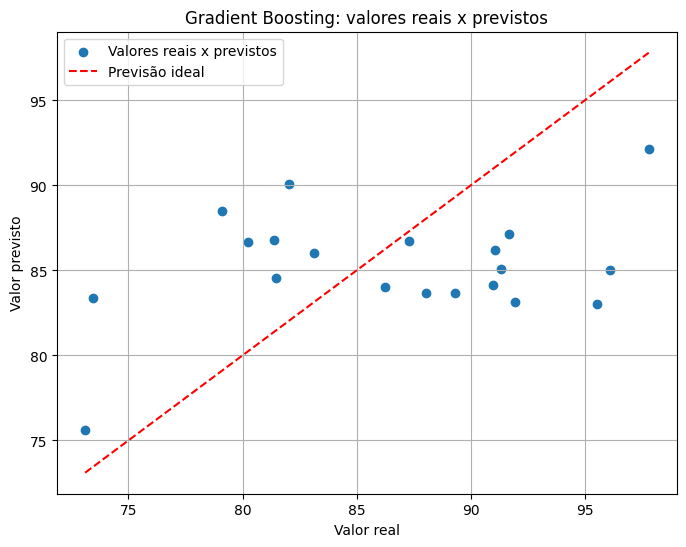

RMSE: 6.7932
MAE: 6.0602
R²: 0.0394


In [47]:
#@title 5.4.4 - Plotando o melhor modelo de GB
plt.figure(figsize=(8, 6))
plt.scatter(
    y_test,
    y_pred_gb_chosen,
    label='Valores reais x previstos'
)
# Linha ideal: previsão igual ao valor real
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    'r--',
    label='Previsão ideal'
)
plt.xlabel("Valor real")
plt.ylabel("Valor previsto")
plt.title(
    "Gradient Boosting: valores reais x previstos"
)
plt.grid(True)
plt.legend()
plt.show()
print(f"RMSE: {gb_rmse:.4f}")
print(f"MAE: {gb_mae:.4f}")
print(f"R²: {gb_r2:.4f}")

In [48]:
#@title 5.4.5 - Importância das variáveis
modelo_GB_chosen = (
    pipeline_GB_chosen
    .named_steps['gradientboosting']
)
# Criando o DataFrame das importâncias
df_importanciasGB = pd.DataFrame({
    'Variável': rom_cols,
    'Importância':
        modelo_GB_chosen.feature_importances_
})
df_importanciasGB = (
    df_importanciasGB
    .sort_values(
        by='Importância',
        ascending=False
    )
    .reset_index(drop=True)
)
display(
    df_importanciasGB.style.format({
        'Importância': '{:.4f}'
    })
)
# Gráfico interativo
fig = px.bar(
    df_importanciasGB.sort_values(
        by='Importância',
        ascending=True
    ),
    x='Importância',
    y='Variável',
    orientation='h',
    title=(
        "Importância das variáveis "
        "no Gradient Boosting"
    )
)
fig.show()

,Variável,Importância
0,%Fe_alim_ROM,0.3318
1,%SiO2_alim_ROM,0.2072
2,%P_alim_ROM,0.2045
3,%Al2O3_alim_ROM,0.0733
4,%CaO_alim_ROM,0.0681
5,%Mn_alim_ROM,0.0466
6,PPC alim_ROM,0.0353
7,%TiO2_alim_ROM,0.0320
8,%MgO_alim_ROM,0.0012


##5.5 - Modelo de Redes Neurais

In [49]:
#@title 5.5.1 - Treinando os melhores modelos de Redes Neurais
from sklearn.neural_network import MLPRegressor
listaMLP = []

#testando redes com 1 camada (10, 50 ou 100 neurônios) e 2 camadas (50,20)
arquiteturas = [(10,), (50,), (100,), (50, 20)]
alphas_mlp = np.logspace(-4, 1, 6) #diferentes taxas de penalidade L2

#pipeline
pipelineMLP = Pipeline([
    ('scaler', StandardScaler()),
    ('mlp', MLPRegressor(
        random_state=42,
        max_iter=3000,
        early_stopping=True, #evitar overfitting
        learning_rate_init=0.01
    ))
])

i = 1
for arch in arquiteturas:
    for a in alphas_mlp:
        #hiperparâmetros
        pipelineMLP.set_params(mlp__hidden_layer_sizes=arch, mlp__alpha=a)

        #treinamento
        pipelineMLP.fit(X_train, y_train)

        #previsão
        y_pred_mlp = pipelineMLP.predict(X_test)

        #métricas
        rmse = np.sqrt(mean_squared_error(y_test, y_pred_mlp))
        mae = mean_absolute_error(y_test, y_pred_mlp)
        r2 = r2_score(y_test, y_pred_mlp)

        listaMLP.append({
            'ID': i,
            'Modelo': 'MLPRegressor',
            'Camadas Ocultas': str(arch),
            'Alpha': a,
            'R2': r2,
            'MAE': mae,
            'RMSE': rmse
        })
        i += 1

In [50]:
#@title 5.5.2 - Organizando os resultados das Redes Neurais
#transformando em dataframe e ordenando por R2
df_modelosMLP = pd.DataFrame(listaMLP).sort_values(by='R2', ascending=False).reset_index(drop=True)

print("Melhores resultados Redes Neurais (MLP):")
display(
    df_modelosMLP.head(10).style.format({
        'Alpha': '{:.5f}',
        'R2': '{:.4f}',
        'MAE': '{:.4f}',
        'RMSE': '{:.4f}'
    }).apply(
        lambda linha: destacar_linhas(linha, [0]),
        axis=1
    )
)

Melhores resultados Redes Neurais (MLP):


,ID,Modelo,Camadas Ocultas,Alpha,R2,MAE,RMSE
0,18,MLPRegressor,"(100,)",10.00000,-1.0034,6.7157,9.8105
1,17,MLPRegressor,"(100,)",1.00000,-7.6665,16.2129,20.4047
2,16,MLPRegressor,"(100,)",0.10000,-7.8714,16.3656,20.6445
3,13,MLPRegressor,"(100,)",0.00010,-7.8829,16.3771,20.6579
4,14,MLPRegressor,"(100,)",0.00100,-7.8829,16.3771,20.6579
5,15,MLPRegressor,"(100,)",0.01000,-7.8830,16.3773,20.6580
6,12,MLPRegressor,"(50,)",10.00000,-8.9241,17.1890,21.8350
7,7,MLPRegressor,"(50,)",0.00010,-8.9828,17.2735,21.8994
8,8,MLPRegressor,"(50,)",0.00100,-8.9828,17.2735,21.8994
9,9,MLPRegressor,"(50,)",0.01000,-8.9828,17.2736,21.8994


In [51]:
#@title 5.5.3 - Treinando o melhor modelos de Redes Neurais denovo
#pegando os hiperparâmetros do melhor modelo
melhor_arch_mlp = eval(df_modelosMLP.iloc[0]['Camadas Ocultas']) # Convertendo string de volta para tupla
melhor_alpha_mlp = df_modelosMLP.iloc[0]['Alpha']

print(f"Melhor arquitetura: {melhor_arch_mlp}")
print(f"Melhor alpha: {melhor_alpha_mlp:.5f}")

#treinando novamente o melhor modelo MLP
pipeline_mlp_chosen = Pipeline([
    ('scaler', StandardScaler()),
    ('mlp', MLPRegressor(
        hidden_layer_sizes=melhor_arch_mlp,
        alpha=melhor_alpha_mlp,
        random_state=42,
        max_iter=3000,
        early_stopping=True,
        learning_rate_init=0.01
    ))
])
pipeline_mlp_chosen.fit(X_train, y_train)
y_pred_mlp_chosen = pipeline_mlp_chosen.predict(X_test)
mlp_rmse = np.sqrt(
    mean_squared_error(y_test, y_pred_mlp_chosen)
)
mlp_mae = mean_absolute_error(
    y_test,
    y_pred_mlp_chosen
)
mlp_r2 = r2_score(
    y_test,
    y_pred_mlp_chosen
)
print("\nMétricas do melhor modelo MLP:")
print(f"RMSE: {mlp_rmse:.4f}")
print(f"MAE: {mlp_mae:.4f}")
print(f"R²: {mlp_r2:.4f}")

Melhor arquitetura: (100,)
Melhor alpha: 10.00000

Métricas do melhor modelo MLP:
RMSE: 9.8105
MAE: 6.7157
R²: -1.0034


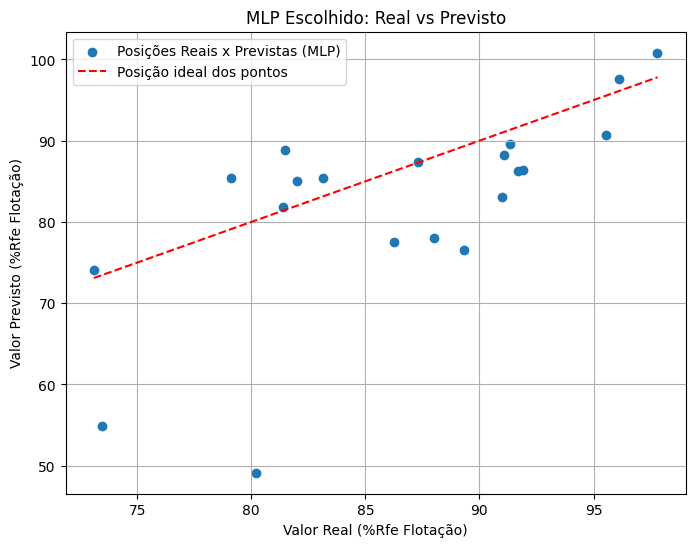

In [52]:
#@title 5.5.4 - Plotando o melhor modelo de Redes Neurais
#plotando MLP escolhido: Real vs Previsto
plt.figure(figsize=(8,6))
plt.scatter(y_test, y_pred_mlp_chosen, label='Posições Reais x Previstas (MLP)')

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    'r--', label='Posição ideal dos pontos'
)

plt.xlabel("Valor Real (%Rfe Flotação)")
plt.ylabel("Valor Previsto (%Rfe Flotação)")
plt.title(f"MLP Escolhido: Real vs Previsto")
plt.grid(True)
plt.legend()
plt.show()

In [53]:
#@title 5.5.5 - Importância das variáveis na Rede Neural
# Calculando a importância por permutação
resultado_importancia_mlp = permutation_importance(
    pipeline_mlp_chosen,
    X_test,
    y_test,
    scoring='r2',
    n_repeats=30,
    random_state=42,
    n_jobs=-1
)
# Criando o DataFrame com os resultados
df_importanciasMLP = pd.DataFrame({
    'Variável': rom_cols,
    'Importância': (
        resultado_importancia_mlp.importances_mean
    ),
    'Desvio_Padrão': (
        resultado_importancia_mlp.importances_std
    )
})
# Organizando da variável mais importante para a menos importante
df_importanciasMLP = (
    df_importanciasMLP
    .sort_values(
        by='Importância',
        ascending=False
    )
    .reset_index(drop=True)
)
print(
    "Importância das variáveis "
    "na Rede Neural:"
)
display(
    df_importanciasMLP.style.format({
        'Importância': '{:.4f}',
        'Desvio_Padrão': '{:.4f}'
    }).apply(
        lambda linha: destacar_linhas(
            linha,
            [0]
        ),
        axis=1
    )
)
# Gráfico interativo
fig = px.bar(
    df_importanciasMLP.sort_values(
        by='Importância',
        ascending=True
    ),
    x='Importância',
    y='Variável',
    error_x='Desvio_Padrão',
    orientation='h',
    title=(
        "Importância das variáveis "
        "na Rede Neural"
    )
)
fig.update_layout(
    xaxis_title="Redução média do R²",
    yaxis_title="Variável"
)
fig.show()

Importância das variáveis na Rede Neural:


,Variável,Importância,Desvio_Padrão
0,%SiO2_alim_ROM,2.0672,0.6614
1,%Fe_alim_ROM,0.1821,0.1862
2,PPC alim_ROM,0.1516,0.1820
3,%Al2O3_alim_ROM,0.0534,0.4353
4,%CaO_alim_ROM,-0.0298,0.0997
5,%P_alim_ROM,-0.0805,0.0513
6,%MgO_alim_ROM,-0.1229,0.2603
7,%TiO2_alim_ROM,-0.4397,0.2939
8,%Mn_alim_ROM,-0.5267,0.1716


#**6 - Resultados**

## 6.1 - Comparação geral

In [54]:
#@title 6.1.1 - Fazendo tabela pra comparação
resultados_comparacao = [
    {
        'Modelo': 'Base',
        'R2': base_r2,
        'MAE': base_mae,
        'RMSE': base_rmse
    },
    {
        'Modelo': 'Lasso',
        'R2': lasso_r2,
        'MAE': lasso_mae,
        'RMSE': lasso_rmse
    },
    {
        'Modelo': 'Ridge',
        'R2': ridge_r2,
        'MAE': ridge_mae,
        'RMSE': ridge_rmse
    },
    {
        'Modelo': 'Elastic Net',
        'R2': elasticnet_r2,
        'MAE': elasticnet_mae,
        'RMSE': elasticnet_rmse
    },
    {
        'Modelo': 'SVR',
        'R2': svr_chosen['R2'].iloc[0],
        'MAE': svr_chosen['MAE'].iloc[0],
        'RMSE': svr_chosen['RMSE'].iloc[0]
    },
    {
        'Modelo': 'Decision Tree',
        'R2': dt_r2,
        'MAE': dt_mae,
        'RMSE': dt_rmse
    },
    {
        'Modelo': 'Random Forest',
        'R2': rf_r2,
        'MAE': rf_mae,
        'RMSE': rf_rmse
    },
    {
        'Modelo': 'Gradient Boosting',
        'R2': gb_r2,
        'MAE': gb_mae,
        'RMSE': gb_rmse
    },
    {
        'Modelo': 'Rede Neural',
        'R2': mlp_r2,
        'MAE': mlp_mae,
        'RMSE': mlp_rmse
    }
]
df_comparacao_geral = pd.DataFrame(resultados_comparacao)


In [55]:
#@title 6.1.2 - Melhores hiperparâmetros de cada Modelo
melhor_lasso = df_modelos_lasso.iloc[0]
melhor_ridge = df_modelos_ridge.iloc[0]
melhor_en = df_modelosEN.iloc[0]
melhor_svr = svr_chosen.iloc[0]
melhor_dt = df_modelosDT.iloc[0]
melhor_rf = df_modelosRF.iloc[0]
melhor_gb = df_modelosGB.iloc[0]
melhor_mlp = df_modelosMLP.iloc[0]
# Criando a tabela com os melhores hiperparâmetros
melhores_hiperparametros = [
    {"Modelo": "Linear"},
    {"Modelo": "Lasso", "alpha": round(melhor_lasso["Alpha"], 5)},
    {"Modelo": "Ridge", "alpha": round(melhor_ridge["Alpha"], 5)},
    {
        "Modelo": "Elastic Net",
        "alpha": round(melhor_en["Alpha"], 5),
        "l1_ratio": round(melhor_en["L1_Ratio"], 2),
    },
    {
        "Modelo": "SVR",
        "C": round(melhor_svr["C"], 2),
        "epsilon": round(melhor_svr["Epsilon"], 2),
    },
    {
        "Modelo": "Decision Tree",
        "max_depth": melhor_dt["Max_Depth"],
        "min_samples_split": melhor_dt["Min_Samples_Split"],
    },
    {
        "Modelo": "Random Forest",
        "n_estimators": melhor_rf["N_Estimators"],
        "max_depth": melhor_rf["Max_Depth"],
    },
    {
        "Modelo": "Gradient Boosting",
        "n_estimators": melhor_gb["N_Estimators"],
        "max_depth": melhor_gb["Max_Depth"],
        "learning_rate": round(melhor_gb["Learning_Rate"], 5),
        "loss": melhor_gb["Loss"],
    },
    {
        "Modelo": "Rede Neural",
        "hidden_layers": melhor_arch_mlp,
        "alpha": round(melhor_alpha_mlp, 5),
    },
]
df_melhores_hiperparametros = pd.DataFrame(melhores_hiperparametros)
display(df_melhores_hiperparametros.fillna("-"))

,Modelo,alpha,l1_ratio,C,epsilon,max_depth,min_samples_split,n_estimators,learning_rate,loss,hidden_layers
0,Linear,-,-,-,-,-,-,-,-,-,-
1,Lasso,0.53367,-,-,-,-,-,-,-,-,-
2,Ridge,7.74264,-,-,-,-,-,-,-,-,-
3,Elastic Net,0.44984,0.9,-,-,-,-,-,-,-,-
4,SVR,-,-,20.0,0.1,-,-,-,-,-,-
5,Decision Tree,-,-,-,-,3.0,2.0,-,-,-,-
6,Random Forest,-,-,-,-,10.0,-,100.0,-,-,-
7,Gradient Boosting,-,-,-,-,6.0,-,290.0,0.0025,huber,-
8,Rede Neural,10.0,-,-,-,-,-,-,-,-,"(100,)"


In [56]:
#@title 6.1.3 - Ordenando pelo R²
df_comparacao_geral = df_comparacao_geral.sort_values(
    by='R2',
    ascending=False
).reset_index(drop=True)
print("Comparação geral dos modelos:")
display(
    df_comparacao_geral.style.format({
        'R2': '{:.4f}',
        'MAE': '{:.4f}',
        'RMSE': '{:.4f}'
    })
)
print("\nQuanto da variação dos dados é explicada pelo modelo")

Comparação geral dos modelos:


,Modelo,R2,MAE,RMSE
0,Lasso,0.6601,3.3920,4.0412
1,Elastic Net,0.6337,3.6293,4.1950
2,Ridge,0.5969,3.7789,4.4008
3,SVR,0.5057,4.1370,4.8731
4,Base,0.1328,5.3728,6.4545
5,Random Forest,0.1163,5.6868,6.5158
6,Gradient Boosting,0.0394,6.0602,6.7932
7,Rede Neural,-1.0034,6.7157,9.8105
8,Decision Tree,-1.0064,8.4614,9.8179



Quanto da variação dos dados é explicada pelo modelo


In [57]:
#@title 6.1.4 - Ordenando pelo MAE
df_comparacao_geral = df_comparacao_geral.sort_values(
    by='MAE',
    ascending=True
).reset_index(drop=True)
print("Comparação geral dos modelos:")
display(
    df_comparacao_geral.style.format({
        'R2': '{:.4f}',
        'MAE': '{:.4f}',
        'RMSE': '{:.4f}'
    })
)
print("\nMede o quanto o modelo errou ( quanto maior, mais erros)")

Comparação geral dos modelos:


,Modelo,R2,MAE,RMSE
0,Lasso,0.6601,3.3920,4.0412
1,Elastic Net,0.6337,3.6293,4.1950
2,Ridge,0.5969,3.7789,4.4008
3,SVR,0.5057,4.1370,4.8731
4,Base,0.1328,5.3728,6.4545
5,Random Forest,0.1163,5.6868,6.5158
6,Gradient Boosting,0.0394,6.0602,6.7932
7,Rede Neural,-1.0034,6.7157,9.8105
8,Decision Tree,-1.0064,8.4614,9.8179



Mede o quanto o modelo errou ( quanto maior, mais erros)


In [58]:
#@title 6.1.5 - Ordenando pelo RMSE
df_comparacao_geral = df_comparacao_geral.sort_values(
    by='RMSE',
    ascending=True
).reset_index(drop=True)
print("Comparação geral dos modelos:")
display(
    df_comparacao_geral.style.format({
        'R2': '{:.4f}',
        'MAE': '{:.4f}',
        'RMSE': '{:.4f}'
    })
)
print("\nMede o quanto o modelo errou, penalizando mais os erros grandes ( quanto maior, mais erros)")

Comparação geral dos modelos:


,Modelo,R2,MAE,RMSE
0,Lasso,0.6601,3.3920,4.0412
1,Elastic Net,0.6337,3.6293,4.1950
2,Ridge,0.5969,3.7789,4.4008
3,SVR,0.5057,4.1370,4.8731
4,Base,0.1328,5.3728,6.4545
5,Random Forest,0.1163,5.6868,6.5158
6,Gradient Boosting,0.0394,6.0602,6.7932
7,Rede Neural,-1.0034,6.7157,9.8105
8,Decision Tree,-1.0064,8.4614,9.8179



Mede o quanto o modelo errou, penalizando mais os erros grandes ( quanto maior, mais erros)


##6.2 - Envio da tabela para o outro notebook (EDA)

In [63]:
!pip install PyGithub
from github import Github
from google.colab import userdata

In [64]:
# --- 1. CONFIGURAÇÕES ---
REPO_OWNER = "leonetk"
REPO_NAME = "ICJ-Lab-Geomet"
GITHUB_TOKEN = userdata.get("GITHUB_PAT_ICJ")  # Secret do Colab

# Informações para o commit (ajuste com seu nome/email do GitHub)
GIT_USER_NAME = "Seu Nome"
GIT_USER_EMAIL = "seu-email@exemplo.com"
COMMIT_MESSAGE = "Adiciona scripts e análises do Colab"

# --- 2. POSICIONAR NA PASTA DO PROJETO ---
local_dir = f"/content/{REPO_NAME}"

if os.path.exists(local_dir):
    %cd {local_dir}
else:
    raise FileNotFoundError(f"A pasta {local_dir} não existe. Você precisa clonar o repositório primeiro.")

# --- 3. CONFIGURAR AUTENTICAÇÃO E IDENTIDADE ---
# Configura o email e nome para a assinatura do commit
!git config user.name "{GIT_USER_NAME}"
!git config user.email "{GIT_USER_EMAIL}"

# Atualiza a URL com o token sem exibir a variável na tela
repo_url = f"https://{GITHUB_TOKEN}@github.com/{REPO_OWNER}/{REPO_NAME}.git"
!git remote set-url origin {repo_url}

# --- 4. EXECUTAR GIT ADD, COMMIT E PUSH ---
# Descobre o nome da branch em que você está posicionado atualmente
current_branch = !git branch --show-current
branch_name = current_branch[0].strip()

print(f"📌 Trabalhando na branch: {branch_name}\n")


FileNotFoundError: A pasta /content/ICJ-Lab-Geomet não existe. Você precisa clonar o repositório primeiro.

In [ ]:
# Adiciona todos os arquivos alterados/novos
!git add .

# Faz o commit (se não houver alterações, o Git avisa)
!git commit -m "{COMMIT_MESSAGE}"

# Envia para o GitHub na branch atual
!git push -u origin {branch_name}

In [ ]:
#@title 6.2.1 - Tabela

#csv_comparacao_geral = df_comparacao_geral.to_csv(index=False)
#caminho_tabela = "modelos+metricas/csv_comparacao_geral.csv"

#try:
    #file = repo.get_contents(caminho_tabela)
    #repo.update_file(
        #path=caminho_tabela,
        #message="Atualiza tabela via PyGithub",
        ##content=csv_comparacao_geral,
        #sha=file.sha,
    #)
    #print("Tabela atualizada!")
#except Exception:
    # Se o arquivo não existir, cria um novo
    #repo.create_file(
        #path=caminho_tabela,
        #message="Cria tabela via PyGithub",
        #content=csv_comparacao_geral,
    #)
    #print("Tabela criada!")

In [ ]:
#@title 6.2.1 - Modelos

#7 - ToDo

- Resolver como vai ser o outro colab de EDA
- Fazer a pesquisa de todos os modelos



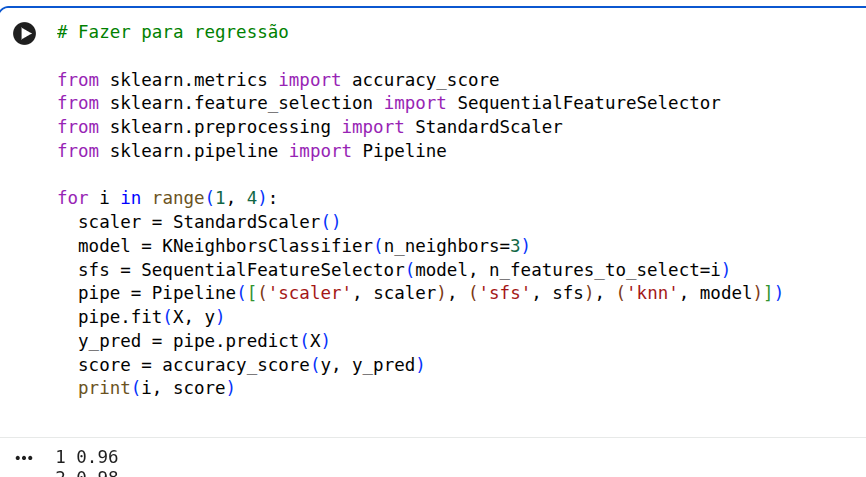

#8 - Qr Code



In [ ]:
#@title 8.1 - Qr code desse colab
!pip install qrcode[PIL]
import qrcode

# Defina o texto ou o link que deseja colocar no QR Code
link = "https://colab.research.google.com/drive/1qBC5DPe9hLLqVO9y_RDEHG9JR3xDh2oN#scrollTo=ZB1DzIxORUS3"

# Crie a imagem do QR code
img = qrcode.make(link)

# Salve a imagem (opcional)
img.save("qrcode.png")

# Exiba a imagem no próprio Colab
display(img)

In [ ]:
#@title 8.2 - Qr code CSV (Geomet_iron.csv)
# Defina o texto ou o link que deseja colocar no QR Code
link = "https://drive.google.com/file/d/1Le5ZoHMw0137tKVgfnSSX-JsL4dvaKo-/view?usp=sharing"

# Crie a imagem do QR code
img = qrcode.make(link)

# Salve a imagem (opcional)
img.save("qrcode.png")

# Exiba a imagem no próprio Colab
display(img)